In [41]:
import platform
import warnings

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Dense

# 한글 경고 제거
warnings.filterwarnings(action="ignore", category=UserWarning)

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [42]:
# fashion_mnist 데이터 가져오기
(train_input, train_target), (test_input, test_target) = fashion_mnist.load_data()

print("train_input :", train_input.shape)
print("train_target:", train_target.shape)

print("test_input  :", test_input.shape)
print("test_target :", test_target.shape)

train_input : (60000, 28, 28)
train_target: (60000,)
test_input  : (10000, 28, 28)
test_target : (10000,)


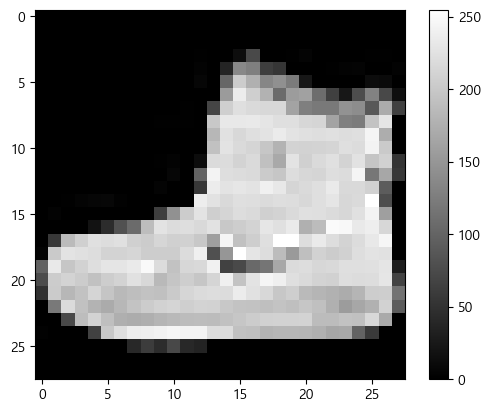

9


In [43]:
# 첫 번째 이미지 확인
# train_input[0]이 실제로 어떤 의류 이미지인지 시각적으로 확인
plt.imshow(train_input[0], cmap="gray")
plt.colorbar()
plt.show()

print(train_target[0])

In [45]:
# 클래스 이름 정의 및 정답 확인
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(class_names[train_target[0]])

Ankle boot


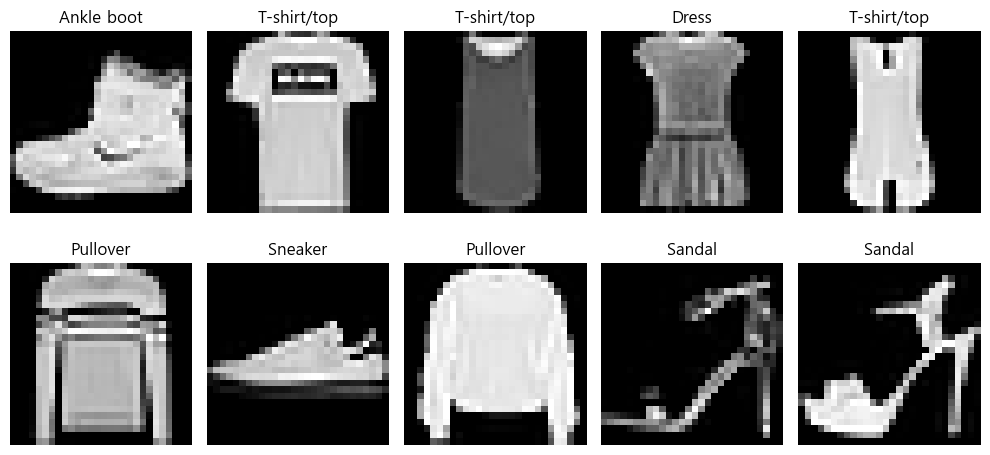

In [46]:
# 샘플 이미지 10장 시각화
# 티셔츠, 바지, 가방 등이 정상적으로 로드되었는지 확인
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(train_input[i], cmap="gray")
    ax.set_title(class_names[train_target[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [47]:
# 픽셀값 범위 확인
# 검은색=0, 흰색=255
print(train_input.min())
print(train_input.max())

0
255


In [48]:
# 0~255 범위를 0~1로 정규화
# 255 → 1.0, 128 → 0.50 으로 변환
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

In [49]:
# 정규화 결과 확인
# 최소값 0.0, 최대값 1.0인지 확인
print(train_scaled.min())
print(train_scaled.max())

0.0
1.0


In [50]:
# 데이터 타입 확인
print(train_input.dtype)
print(train_scaled.dtype)

uint8
float64


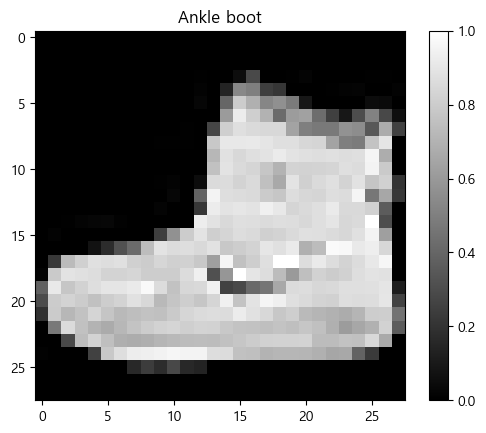

In [51]:
# 정규화 후 이미지 확인
# 화면은 같아 보이지만 내부 값은 0~1 범위로 변경됨
plt.imshow(train_scaled[0], cmap="gray")
plt.title(class_names[train_target[0]])
plt.colorbar()
plt.show()

In [52]:
# 28×28 이미지를 784개 특성으로 변환
train_scaled = train_scaled.reshape(-1, 28 * 28)
test_scaled = test_scaled.reshape(-1, 28 * 28)

# 변환 후 데이터 크기 확인
print(train_scaled.shape)
print(test_scaled.shape)

(60000, 784)
(10000, 784)


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# 훈련용과 검증용 데이터 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [55]:
# 분리된 데이터 크기 확인
print("train_scaled:", train_scaled.shape)
print("val_scaled  :", val_scaled.shape)

print("train_target:", train_target.shape)
print("val_target  :", val_target.shape)

train_scaled: (48000, 784)
val_scaled  : (12000, 784)
train_target: (48000,)
val_target  : (12000,)


### Train / Validation / Test 역할

- Train : 모델 학습
- Validation : 과적합 감시
- Test : 최종 성능 평가

In [56]:
# 단층 Softmax 모델 생성
# 784개 입력 → 10개 의류 클래스 확률 출력
model = Sequential([Dense(10, activation="softmax", input_shape=(784,))])

In [57]:
# 모델 구조 및 파라미터 확인
# 784×10 + bias 10 = 총 7850개 파라미터
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# 모델 컴파일
# 모델 학습 방식 설정
# Adam 옵티마이저를 사용하여 가중치를 자동 업데이트
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
# optimizer="adam" -> 가중치(w)를 어떻게 업데이트할지 결정

In [59]:
# 모델 학습
# 전체 학습 데이터를 10번 반복 학습(epoch=10)
history = model.fit(
    train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target)
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - accuracy: 0.7888 - loss: 0.6235 - val_accuracy: 0.8303 - val_loss: 0.4997
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 0.8397 - loss: 0.4712 - val_accuracy: 0.8382 - val_loss: 0.4653
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.8485 - loss: 0.4417 - val_accuracy: 0.8481 - val_loss: 0.4407
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8535 - loss: 0.4285 - val_accuracy: 0.8407 - val_loss: 0.4524
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8559 - loss: 0.4166 - val_accuracy: 0.8497 - val_loss: 0.4326
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.8586 - loss: 0.4092 - val_accuracy: 0.8528 - val_loss: 0.4244
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8603 - loss: 0.4046 - val_accuracy: 0.8480 - val_loss: 0.4330
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step - accuracy: 0.8618 -

In [72]:
pred = model.predict(test_scaled[:1])

print(pred)
print("확률 합:", pred.sum())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[4.9721245e-07 5.1353965e-08 2.4971265e-05 1.8247480e-05 9.1254324e-06
  1.6103685e-01 4.9192986e-05 1.1887431e-01 1.6230160e-02 7.0375651e-01]]
확률 합: 0.99999994


In [60]:
# 검증 데이터 성능 평가
# 학습에 사용하지 않은 데이터로 정확도 측정
val_loss, val_acc = model.evaluate(val_scaled, val_target)

print("Validation Loss :", val_loss)
print("Validation Accuracy :", val_acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8510 - loss: 0.4290
Validation Loss : 0.4289758801460266
Validation Accuracy : 0.8510000109672546


In [61]:
# 학습 기록 확인
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [62]:
history.history["accuracy"]
history.history["val_accuracy"]

[0.8302500247955322,
 0.8382499814033508,
 0.8480833172798157,
 0.840666651725769,
 0.8496666550636292,
 0.8527500033378601,
 0.8479999899864197,
 0.8512499928474426,
 0.8525833487510681,
 0.8510000109672546]

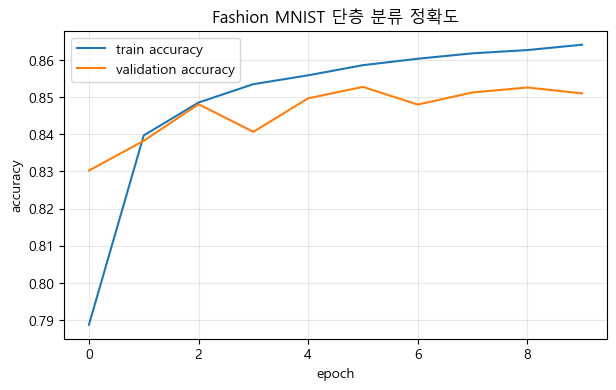

In [63]:
# Epoch별 정확도 변화 시각화
plt.figure(figsize=(7, 4))

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Fashion MNIST 단층 분류 정확도")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

학습이 진행될수록 Train Accuracy와 Validation Accuracy가 모두 증가하였다.

Epoch 3 이후부터 Validation Accuracy는 약 85% 수준에서 수렴하는 모습을 보였으며, Train Accuracy와 Validation Accuracy의 차이가 크지 않아 과적합은 거의 발생하지 않았다.

현재 모델은 Dense(10)으로 구성된 단층 Softmax 분류기이므로 표현력에 한계가 있으며, 이후 은닉층(ReLU)을 추가하면 더 높은 성능을 기대할 수 있다.


---
#### Fashion MNIST 은닉층 구조 실험

In [64]:
# 실험 결과를 저장할 리스트 생성
# 모델명, 파라미터 수, 정확도를 저장하여 비교
results = []

In [65]:
# 앞에서 학습한 단층 모델의 결과 저장
results.append(
    {
        "model": "단층",
        "structure": "Dense(10)",
        "params": model.count_params(),
        "val_accuracy": val_acc,
    }
)

results

[{'model': '단층',
  'structure': 'Dense(10)',
  'params': 7850,
  'val_accuracy': 0.8510000109672546}]

In [66]:
# 은닉층 64개를 가진 모델 생성
model_64 = Sequential(
    [Dense(64, activation="relu", input_shape=(784,)), Dense(10, activation="softmax")]
)

# 모델 구조와 파라미터 수 확인
model_64.summary()

# 모델 컴파일
model_64.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 모델 학습
history_64 = model_64.fit(
    train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target)
)

# 검증 성능 평가
val_loss_64, val_acc_64 = model_64.evaluate(val_scaled, val_target)

# 실험 결과 저장
results.append(
    {
        "model": "은닉층 64",
        "structure": "Dense(64) → Dense(10)",
        "params": model_64.count_params(),
        "val_accuracy": val_acc_64,
    }
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8137 - loss: 0.5390 - val_accuracy: 0.8409 - val_loss: 0.4560
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8571 - loss: 0.4043 - val_accuracy: 0.8594 - val_loss: 0.4053
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8689 - loss: 0.3660 - val_accuracy: 0.8715 - val_loss: 0.3614
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8766 - loss: 0.3421 - val_accuracy: 0.8634 - val_loss: 0.3795
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8835 - loss: 0.3204 - val_accuracy: 0.8768 - val_loss: 0.3409
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8889 - loss: 0.3057 - val_accuracy: 0.8765 - val_loss: 0.3502
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8918 - loss: 0.2948 - val_accuracy: 0.8759 - val_loss: 0.3436
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8974 - loss: 0.2818 - 

In [67]:
# 현재까지의 실험 결과 확인
results

[{'model': '단층',
  'structure': 'Dense(10)',
  'params': 7850,
  'val_accuracy': 0.8510000109672546},
 {'model': '은닉층 64',
  'structure': 'Dense(64) → Dense(10)',
  'params': 50890,
  'val_accuracy': 0.877916693687439}]

In [68]:
# 은닉층 128개를 가진 모델 생성
model_128 = Sequential(
    [Dense(128, activation="relu", input_shape=(784,)), Dense(10, activation="softmax")]
)

# 모델 구조와 파라미터 수 확인
model_128.summary()

# 모델 컴파일
model_128.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 모델 학습
history_128 = model_128.fit(
    train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target)
)

# 검증 성능 평가
val_loss_128, val_acc_128 = model_128.evaluate(val_scaled, val_target)

# 실험 결과 저장
results.append(
    {
        "model": "은닉층 128",
        "structure": "Dense(128) → Dense(10)",
        "params": model_128.count_params(),
        "val_accuracy": val_acc_128,
    }
)

# 현재까지의 결과 확인
results

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8191 - loss: 0.5166 - val_accuracy: 0.8587 - val_loss: 0.3964
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8608 - loss: 0.3860 - val_accuracy: 0.8647 - val_loss: 0.3731
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8758 - loss: 0.3428 - val_accuracy: 0.8653 - val_loss: 0.3658
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8826 - loss: 0.3196 - val_accuracy: 0.8733 - val_loss: 0.3556
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8891 - loss: 0.3014 - val_accuracy: 0.8815 - val_loss: 0.3280
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8948 - loss: 0.2845 - val_accuracy: 0.8805 - val_loss: 0.3297
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8991 - loss: 0.2722 - val_accuracy: 0.8786 - val_loss: 0.3457
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9046 - loss: 0.2602 - 

[{'model': '단층',
  'structure': 'Dense(10)',
  'params': 7850,
  'val_accuracy': 0.8510000109672546},
 {'model': '은닉층 64',
  'structure': 'Dense(64) → Dense(10)',
  'params': 50890,
  'val_accuracy': 0.877916693687439},
 {'model': '은닉층 128',
  'structure': 'Dense(128) → Dense(10)',
  'params': 101770,
  'val_accuracy': 0.8883333206176758}]

In [69]:
# 은닉층 2개를 가진 모델 생성
model_64_32 = Sequential(
    [
        Dense(64, activation="relu", input_shape=(784,)),
        Dense(32, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)

# 모델 구조와 파라미터 수 확인
model_64_32.summary()

# 모델 컴파일
model_64_32.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 모델 학습
history_64_32 = model_64_32.fit(
    train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target)
)

# 검증 성능 평가
val_loss_64_32, val_acc_64_32 = model_64_32.evaluate(val_scaled, val_target)

# 실험 결과 저장
results.append(
    {
        "model": "은닉층 64-32",
        "structure": "Dense(64) → Dense(32) → Dense(10)",
        "params": model_64_32.count_params(),
        "val_accuracy": val_acc_64_32,
    }
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8017 - loss: 0.5691 - val_accuracy: 0.8363 - val_loss: 0.4511
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8547 - loss: 0.4063 - val_accuracy: 0.8608 - val_loss: 0.3893
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8662 - loss: 0.3670 - val_accuracy: 0.8633 - val_loss: 0.3781
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8750 - loss: 0.3399 - val_accuracy: 0.8644 - val_loss: 0.3788
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8820 - loss: 0.3239 - val_accuracy: 0.8679 - val_loss: 0.3630
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8859 - loss: 0.3102 - val_accuracy: 0.8594 - val_loss: 0.3841
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8880 - loss: 0.2981 - val_accuracy: 0.8760 - val_loss: 0.3455
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8939 - loss: 0.2852 - 

In [70]:
# 실험 결과를 DataFrame으로 변환
import pandas as pd

result_df = pd.DataFrame(results)

result_df

,model,structure,params,val_accuracy
0,단층,Dense(10),7850,0.851000
1,은닉층 64,Dense(64) → Dense(10),50890,0.877917
2,은닉층 128,Dense(128) → Dense(10),101770,0.888333
3,은닉층 64-32,Dense(64) → Dense(32) → Dense(10),52650,0.882083


In [71]:
# 정확도가 높은 순으로 정렬
result_df.sort_values(by="val_accuracy", ascending=False)

,model,structure,params,val_accuracy
2,은닉층 128,Dense(128) → Dense(10),101770,0.888333
3,은닉층 64-32,Dense(64) → Dense(32) → Dense(10),52650,0.882083
1,은닉층 64,Dense(64) → Dense(10),50890,0.877917
0,단층,Dense(10),7850,0.851000


### 실험 결과 분석

은닉층을 추가하면 단층 모델보다 더 높은 성능을 얻을 수 있었다.

그러나 파라미터 수가 많다고 항상 성능이 향상되는 것은 아니었다.

모델이 너무 복잡해지면 학습 시간이 증가하고 과적합 위험도 커질 수 있다.

따라서 딥러닝 모델은 단순히 파라미터 수를 늘리는 것이 아니라 데이터 특성에 맞는 적절한 구조를 선택하는 것이 중요하다.